In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from pysheds.grid import Grid
from pysheds.sview import Raster
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import shape
from scipy.ndimage import gaussian_filter, distance_transform_edt
from rasterio.features import shapes
from tqdm import tqdm

In [2]:
watershed = gpd.read_file("GIS/WATERSHEDS.geojson")
watershed = watershed[watershed['NAME'] == 'Popes Head Creek']
watershed = watershed.to_crs('EPSG:26918')

In [ ]:
# load elevation data for particular watershed
with rasterio.open("elevation/fairfax_dem_1m.tif") as src:    
    out_image, out_transform = mask(src, watershed.geometry, crop=True)
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })

with rasterio.open("elevation/popes_head_dem.tif", 'w', **out_meta) as dest:
    dest.write(out_image)

In [3]:
grid = Grid.from_raster("elevation/popes_head_dem.tif")
dem = grid.read_raster("elevation/popes_head_dem.tif")

In [ ]:
plt.imshow(np.where(dem == -9999, np.nan, dem), cmap='terrain')
plt.title('Popes Head Creek DEM')
plt.colorbar(label='Elevation (m)')
plt.axis('off')
plt.show()

In [ ]:
pit_filled = grid.fill_pits(dem)
flooded = grid.fill_depressions(pit_filled)
inflated = grid.resolve_flats(flooded)
flowdir = grid.flowdir(inflated)
acc = grid.accumulation(flowdir)

In [4]:
# with rasterio.open('flowdir.tif', "w",
#     driver="GTiff",
#     height=flowdir.shape[0],
#     width=flowdir.shape[1],
#     count=1,
#     dtype=flowdir.dtype,
#     crs=src.crs,
#     transform=grid.affine) as dst:
#     dst.write(flowdir, 1)

flowdir = grid.read_raster('flowdir.tif')

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/pysheds/io.py:134: UserWarning: No `nodata` value detected. Defaulting to 0.
  warnings.warn('No `nodata` value detected. Defaulting to 0.')


In [ ]:
acc_smooth = np.log10(acc+1)
acc_smooth = gaussian_filter(acc_smooth, sigma=3)
plt.imshow(acc_smooth)
plt.axis('off')
plt.colorbar(label='log2(Accumulation + 1)')
plt.title('Popes Head Creek Smoothed Accumulation')
plt.show()

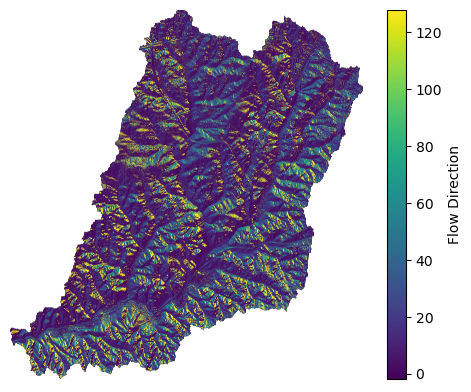

In [5]:
plt.imshow(np.where(dem == -9999, np.nan, flowdir))
plt.axis('off')
plt.colorbar(label='Flow Direction')
plt.show()

## Subcatchment Creation Using Recorded Inlets
Directly apply the recorded stormwater infrastructure data to identify points of urban inflow.

In [ ]:
infrastructure = gpd.read_file('stormnet/13.geojson')
infrastructure = infrastructure.to_crs(watershed.crs).clip(watershed)

In [ ]:
drainage_sources = ['Inlet', 'Infall']
is_source = [infrastructure['TYPE'].str.contains(source) for source in drainage_sources]
is_source = np.logical_or(*is_source)
is_source = np.where(is_source.isna(), False, is_source)
drainage = infrastructure[is_source]

## Identify Land Where Drainage Occurs

In [104]:
subcatchments = np.zeros_like(acc)
mask = np.where(dem == -9999, True, False)
area = np.sum(~mask)
subcatchment_area = 0
geometries = tqdm(drainage.geometry)

sink_patch = np.array([
    [  2,   4,   8  ],  # NW, N, NE
    [ 1,  -2,  16 ],  # W,  PIT,  E
    [128,  64,  32 ]   # SW, S, SE
])

for source in geometries:
    j, i = grid.affine.__invert__()*(source.x, source.y)
    i, j = round(i), round(j)
    
    # manipulate inlet surroundings for water-intake emphasis (better delineation)
    original = flowdir[i-1:i+2, j-1:j+2].copy()
    flowdir[i-1:i+2, j-1:j+2] = sink_patch

    sub = grid.catchment(x=j, y=i, fdir=flowdir, xytype='index')
    flowdir[i-1:i+2, j-1:j+2] = original
    sub = np.where(mask, False, sub)
    mask[i, j] = True
    if not sub.sum():
        continue
    subcatchment_area += sub.sum()
    subcatchments[sub] = 1
    mask = np.logical_or(mask, sub)
    geometries.set_description(f"Area covered - {subcatchment_area/area*100:.2f}%")
    

Area covered - 27.13%: 100%|██████████| 2314/2314 [08:10<00:00,  4.72it/s]


In [287]:
polygons = []
arr = (subcatchments != 0).astype(np.uint8)
for geom, val in shapes(arr, mask=arr==1, transform=grid.affine):
    polygons.append(shape(geom))

In [289]:
polygon_gdf = gpd.GeoDataFrame(
    {"geometry": polygons},
    crs=grid.crs
)

## Delineate drainage land for subcatchments by infalls

In [8]:
nodes = gpd.read_file('nodes.geojson')
edges = gpd.read_file('edges.geojson')

In [411]:
infalls = nodes[nodes.node_type == 'infall'].clip(polygon_gdf)
infall_indices = []
for geom in infalls.geometry:
    j, i = ~grid.affine * (geom.x, geom.y)
    i, j = int(round(i)), int(round(j))
    infall_indices.append((i, j))

In [149]:
infall_mask = np.zeros_like(subcatchments, dtype=bool)

for i, j in infall_indices:
    infall_mask[i, j] = True

distance, nearest_idx = distance_transform_edt(
    ~infall_mask,  # distance to nearest infall
    return_indices=True
)

assigned = np.zeros_like(subcatchments, dtype=int)
for idx, (i, j) in tqdm(list(enumerate(infall_indices, start=1))):
    nearest_i, nearest_j = nearest_idx
    assigned[(nearest_i == i) & (nearest_j == j) & (subcatchments==1)] = idx

100%|██████████| 1204/1204 [02:44<00:00,  7.30it/s]


In [257]:
polygons = []
for label in tqdm(np.unique(assigned[assigned>0])):
    sub = (assigned == label).astype(np.uint8)
    for geom, val in shapes(sub, mask=sub>0, transform=grid.affine):
        polygons.append({
            "geometry": shape(geom)
        })

catchment_gdf = gpd.GeoDataFrame(polygons, crs=grid.crs)

100%|██████████| 1204/1204 [10:57<00:00,  1.83it/s]


In [436]:
subcatchment_gdf = catchment_gdf[catchment_gdf.area >= 100] # ARBITRARY: minimum coverage of 100 m^2
infalls = infalls.clip(subcatchment_gdf)
subcatchment_gdf = gpd.sjoin(subcatchment_gdf, infalls, predicate="covers").drop(columns='index_right').reset_index(drop=True).reset_index().rename(columns={'index': 'subcatchment_id'})

In [336]:
impervious_surfaces = gpd.read_file("GIS/impervious_surfaces/2023_Countywide_Impervious.shp").to_crs(grid.crs).clip(watershed)

/home/javkt/anaconda3/envs/py10/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: GIS/impervious_surfaces/2023_Countywide_Impervious.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [437]:
subcatchment_gdf['geometry'] = subcatchment_gdf.geometry.buffer(0)
impervious_surfaces['geometry'] = impervious_surfaces.geometry.buffer(0)
subcatchment_gdf['pct_impervious'] = subcatchment_gdf.geometry.apply(lambda geom: round(impervious_surfaces.clip(geom).area.sum() / geom.area * 100, 3))

In [438]:
soils = gpd.read_file('GIS/SOIL.geojson').to_crs(grid.crs).clip(watershed)

In [445]:
soils['HYDRO_GROUP'] = soils['HYDRO_GROUP'].replace(['C/D', 'B/D'], 'D').replace('NA', 'C').fillna('C')
green_ampt_params = {
    "A":  {"Ksat": 40, "Suction": 60,  "IMD": 0.30},
    "B":  {"Ksat": 20, "Suction": 110, "IMD": 0.35},
    "C":  {"Ksat": 6,  "Suction": 150, "IMD": 0.40},
    "D":  {"Ksat": 1,  "Suction": 200, "IMD": 0.45}
}
soils[['Ksat', 'Suction', 'IMD']] = soils['HYDRO_GROUP'].apply(
    lambda g: pd.Series(green_ampt_params[g])
)

In [ ]:
joined = gpd.overlay(subcatchment_gdf, soils, how='intersection')
joined['area'] = joined.geometry.area
grouped = joined.groupby('subcatchment_id').apply(
    lambda df: pd.Series({
        "Ksat": (df["area"] * df["Ksat"]).sum() / df["area"].sum(),
        "Suction": (df["area"] * df["Suction"]).sum() / df["area"].sum(),
        "IMD": (df["area"] * df["IMD"]).sum() / df["area"].sum(),
    })
)
subcatchment_gdf = subcatchment_gdf.merge(grouped, on='subcatchment_id')

/tmp/ipykernel_17738/2581819711.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = joined.groupby('subcatchment_id').apply(


In [48]:
# find the max elevation for every subcatchment
for i, sub in tqdm(subcatchment_gdf.iterrows()):
    subset = nodes.clip(sub.geometry)
    max_diff = subset.elevation.max() - subset.elevation.min()
    subcatchment_gdf.loc[i, 'slope'] = max_diff / (sub.geometry.area ** 0.5) * 100

1034it [00:00, 2182.01it/s]


In [34]:
avg_slopes = []
for c, nid in tqdm(zip(subcatchment_gdf.geometry.centroid, subcatchment_gdf.node_id)):
    j, i = ~grid.affine * (c.x, c.y)
    elevation = dem[int(i), int(j)]
    slope = elevation - nodes[nodes.node_id == nid].elevation.values[0]
    nx, ny = float(nid[1:nid.index(',')]), float(nid[nid.index(',')+2:-2])
    dist = np.sqrt((c.x - nx)**2 + (c.y - ny)**2)
    slope = slope / dist
    avg_slopes.append(abs(slope) * 100) # to percentage
subcatchment_gdf['avg_slope'] = avg_slopes 

1034it [00:00, 3127.35it/s]


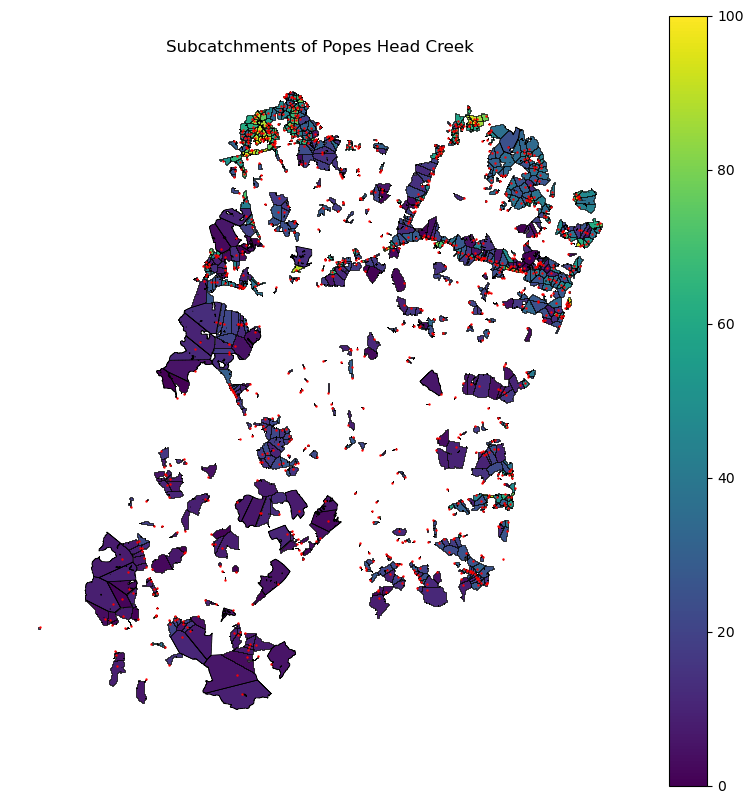

In [457]:
fig, ax = plt.subplots(figsize=(10, 10))
subcatchment_gdf.plot(ax=ax, column='pct_impervious', legend=True, edgecolor='black', linewidth=0.5)
infalls.plot(ax=ax, color='red', markersize=0.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Subcatchments of Popes Head Creek')
plt.show()

In [35]:
subcatchment_gdf.to_file("subcatchments.geojson", driver="GeoJSON")